# Day 5 — Applying the Model to the 1,208 BCUs

Days 1–4 built a Random Forest that separates BL Lacs from FSRQs at CV AUC **0.946 ± 0.009**,
beats spectral index alone by **+0.016 ± 0.007** in 50 of 50 folds, and does so through a
mechanism we could name and test: it uses **variability** to rescue *low-peaked BL Lacs* whose
soft spectra otherwise look like FSRQs.

Today we point it at the 1,208 BCUs. But the BCUs are not the population the model was trained
on — they are systematically fainter — so the day opens with a gate, not a prediction.

### The gate

> A model's cross-validated score is a statement about the population it was validated on.
> Applying it elsewhere is an extrapolation, and extrapolations need to be priced before they
> are made.

So: measure the shift, **pre-register** what the shift should do to performance, test that on
data where we still have labels, and only then predict.

### Today
1. Quantify the shift with a domain classifier — how distinguishable are BCUs from knowns?
2. Pre-register three predictions, before any BCU is scored.
3. **The transfer test**: resample the *labelled* set to look like the BCUs and re-measure the
   forest's advantage. This is the day's central experiment.
4. Estimate how many FSRQs are actually in there — three independent ways that disagree.
5. Predict, threshold, and publish.
6. Ask whether the LBL mechanism from Day 4 replicates on the BCUs.

## 1. Setup

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import StratifiedKFold, cross_val_predict, cross_val_score
from sklearn.metrics import roc_auc_score

RANDOM_STATE = 42

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROCESSED = ROOT / "data" / "processed"
FIGURES = ROOT / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="ticks", context="notebook")
CLASS_COLORS = {"bll": "#2E86AB", "fsrq": "#D1495B"}
UNSURE_COLOR = "#9E9E9E"
ACCENT = "#F2A104"

pd.set_option("display.width", 160)

In [2]:
known = pd.read_csv(PROCESSED / "known_blazars.csv")
bcu = pd.read_csv(PROCESSED / "bcu_candidates.csv")

cfg = json.load(open(PROCESSED / "day3_model_config.json"))
d4 = json.load(open(PROCESSED / "day4_interpretability.json"))

FEATURES = cfg["features"]
BEST_PARAMS = cfg["best_params"]
GAMMA_BOUNDARY = d4["learned_boundary_gamma_median"]

PRETTY = {
    "PL_Index": r"$\Gamma$  (photon index)",
    "log10_Variability_Index": r"$\log_{10}$ Variability",
    "log10_Flux1000": r"$\log_{10}$ Flux(>1 GeV)",
    "Pivot_Energy": "Pivot Energy (MeV)",
}

X = known[FEATURES]
y = (known["CLASS_clean"] == "fsrq").astype(int)
TRAIN_PRIOR = y.mean()

# One model factory used everywhere, so nothing silently diverges between sections.
def make_model():
    return CalibratedClassifierCV(
        RandomForestClassifier(n_jobs=-1, **BEST_PARAMS), method="isotonic", cv=5
    )

CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print(f"labelled blazars : {len(known):5d}   FSRQ fraction (training prior) = {TRAIN_PRIOR:.4f}")
print(f"BCUs to classify : {len(bcu):5d}")
print(f"learned Gamma boundary from Day 4: {GAMMA_BOUNDARY:.3f}")

labelled blazars :  2134   FSRQ fraction (training prior) = 0.3538
BCUs to classify :  1208
learned Gamma boundary from Day 4: 2.251


## 2. The gate — how different are the BCUs?

The clean way to ask "are these two samples from the same distribution?" is to *try to tell them
apart*. Train a classifier whose label is not BL Lac vs FSRQ but **known vs BCU**, on exactly the
four features the real model uses. Its ROC-AUC is a direct measure of covariate shift:

- **0.50** — the two populations are indistinguishable; the model transfers for free.
- **1.00** — completely separable; every prediction is an extrapolation.

Anything in between tells us *how much* of an extrapolation we are making, and the per-feature
version tells us *which* feature is doing the shifting.

In [3]:
domain = pd.concat(
    [known[FEATURES].assign(is_bcu=0), bcu[FEATURES].assign(is_bcu=1)], ignore_index=True
)
domain_clf = RandomForestClassifier(
    n_estimators=400, max_depth=6, class_weight="balanced",
    random_state=RANDOM_STATE, n_jobs=-1,
)
domain_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scores = cross_val_score(domain_clf, domain[FEATURES], domain["is_bcu"],
                         cv=domain_cv, scoring="roc_auc", n_jobs=-1)
domain_auc = scores.mean()
print(f"domain-classifier AUC (all four features) = {domain_auc:.4f} +/- {scores.std():.4f}\n")

per_feature = {}
for f in FEATURES:
    per_feature[f] = cross_val_score(domain_clf, domain[[f]], domain["is_bcu"],
                                     cv=domain_cv, scoring="roc_auc", n_jobs=-1).mean()

shift = pd.DataFrame({
    "known mean": [known[f].mean() for f in FEATURES],
    "BCU mean": [bcu[f].mean() for f in FEATURES],
    "shift (known sd)": [(bcu[f].mean() - known[f].mean()) / known[f].std() for f in FEATURES],
    "domain AUC alone": [per_feature[f] for f in FEATURES],
}, index=[PRETTY[f] for f in FEATURES])
print(shift.round(3).to_string())

domain-classifier AUC (all four features) = 0.7394 +/- 0.0044



                          known mean  BCU mean  shift (known sd)  domain AUC alone
$\Gamma$  (photon index)       2.185     2.258             0.247             0.557
$\log_{10}$ Variability        1.602     1.288            -0.470             0.636
$\log_{10}$ Flux(>1 GeV)      -9.409    -9.738            -0.655             0.699
Pivot Energy (MeV)          2452.493  2758.857             0.117             0.537


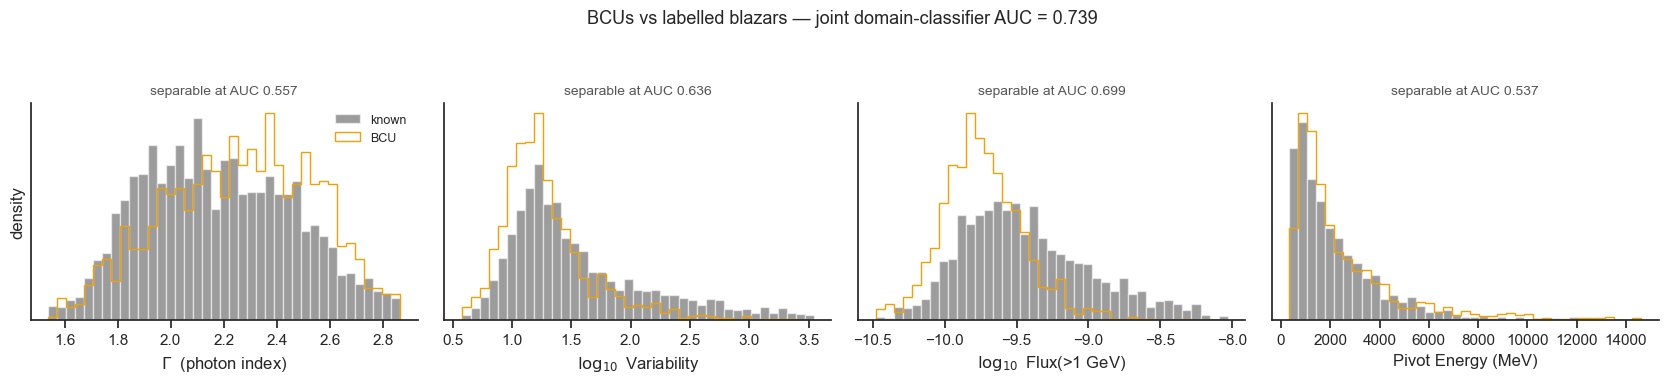

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(17, 3.6))
for ax, f in zip(axes, FEATURES):
    lo, hi = np.percentile(np.r_[known[f], bcu[f]], [0.5, 99])
    bins = np.linspace(lo, hi, 40)
    ax.hist(known[f], bins=bins, density=True, alpha=0.55, color="#4C4C4C", label="known")
    ax.hist(bcu[f], bins=bins, density=True, histtype="step", lw=2.2, color=ACCENT, label="BCU")
    ax.set_xlabel(PRETTY[f])
    ax.set_yticks([])
    ax.set_title(f"separable at AUC {per_feature[f]:.3f}", fontsize=10, color="#555555")
axes[0].set_ylabel("density")
axes[0].legend(frameon=False, fontsize=9)
fig.suptitle(
    f"BCUs vs labelled blazars — joint domain-classifier AUC = {domain_auc:.3f}",
    y=1.06, fontsize=13,
)
sns.despine(fig)
fig.tight_layout()
fig.savefig(FIGURES / "day5_distribution_shift.png", dpi=150, bbox_inches="tight")
plt.show()

**AUC 0.739 — a real but not catastrophic shift, and flux is what moves.**

Flux alone separates the two populations at 0.699; spectral index alone manages only 0.557. That
ordering is exactly what a flux-limited survey produces. BCUs are unclassified *because* they are
faint — a faint source has a dim optical counterpart, so nobody has taken the spectrum that would
sort it. Faintness is the cause of the missing label, so faintness is guaranteed to be the axis
along which the two samples differ.

The dangerous consequence is in the second column: **variability shifts down by 0.47 sd**. The
Variability_Index is a χ²-like statistic, and its sensitivity scales with flux — a faint source
cannot show significant variability even if it truly varies. So the BCUs look quiet, and Day 4
established that "quiet" is precisely the evidence the forest uses to call something a BL Lac.

That gives us a concrete, falsifiable worry rather than a vague one:

> The forest's advantage over spectral index comes from variability. Variability is degraded on
> faint sources. The BCUs are faint. Therefore the advantage should shrink — possibly to nothing.

## 3. Pre-registered predictions

Written before a single BCU is scored, so today's conclusions can fail.

> **P1 — The advantage does not transfer.** On a labelled sample resampled to match the BCU flux
> distribution, the forest's margin over Γ alone will be **smaller than +0.016**.
>
> **P2 — The model will be less certain than it was on the knowns.** Coverage at the
> `P ≥ 0.90 / ≤ 0.10` threshold will fall below the 71% measured on the labelled set.
>
> **P3 — The model will under-call FSRQs.** Because BCU variability is artificially suppressed
> and low variability reads as "BL Lac", the model's implied FSRQ fraction will come in *below*
> an independent estimate made from spectral index alone.

P1 is the load-bearing one. If it fails, the honest report is that four features were not worth
the trouble and a cut on Γ would have done.

## 4. The transfer test

We cannot measure performance on the BCUs — that's the whole problem. But we can build a
labelled population that *looks like* the BCUs and measure performance there.

**Method: rejection sampling on flux.** Bin log-flux into deciles over the pooled sample, form
the importance weight $w_b = p_\mathrm{BCU}(b) / p_\mathrm{known}(b)$, and keep each labelled
source with probability $w_b / \max_b w_b$. The survivors are labelled blazars drawn from the
BCU flux distribution.

**One trap, worth naming.** The obvious implementation — bootstrap-resample *with replacement*
using those weights — is wrong, and wrong in the flattering direction: duplicated sources land in
both the training and test folds of the same CV split, which is leakage. Written that way, the
"harder" faint sample scores *higher* than the full sample. Rejection sampling keeps every source
at most once and has no such leak.

**And a control.** Rejection sampling also shrinks the sample (2,134 → ≈991). Any drop in
performance could just be less training data. So we run the identical experiment on a *random*
subsample of the same size. If flux-matching hurts and random subsampling doesn't, the cause is
faintness, not sample size.

In [5]:
# Importance weights over pooled log-flux deciles.
edges = np.quantile(np.r_[known["log10_Flux1000"], bcu["log10_Flux1000"]], np.linspace(0, 1, 11))
edges[0] -= 1e-6
edges[-1] += 1e-6
known_bin = pd.cut(known["log10_Flux1000"], edges, labels=False)
bcu_bin = pd.cut(bcu["log10_Flux1000"], edges, labels=False)

p_known = known_bin.value_counts(normalize=True).sort_index()
p_bcu = bcu_bin.value_counts(normalize=True).sort_index()
weights = (p_bcu / p_known).reindex(range(10)).fillna(0.0)
accept = (known_bin.map(weights) / weights.max()).to_numpy()

print("flux decile:  BCU density / known density")
for b, w in weights.items():
    bar = "#" * int(round(w * 18))
    print(f"  decile {b}  {w:5.3f}  {bar}")

flux decile:  BCU density / known density
  decile 0  2.153  #######################################
  decile 1  2.065  #####################################
  decile 2  1.746  ###############################
  decile 3  1.898  ##################################
  decile 4  1.291  #######################
  decile 5  1.112  ####################
  decile 6  0.844  ###############
  decile 7  0.503  #########
  decile 8  0.247  ####
  decile 9  0.066  #


In [6]:
# Out-of-fold RF AUC and Gamma-alone AUC on one labelled sample.
def cv_pair(sample):
    ys = (sample["CLASS_clean"] == "fsrq").astype(int)
    p = cross_val_predict(RandomForestClassifier(n_jobs=-1, **BEST_PARAMS),
                          sample[FEATURES], ys, cv=CV, method="predict_proba")[:, 1]
    # Gamma needs no fitting: higher Gamma already means "more FSRQ-like", so it is the score.
    return roc_auc_score(ys, p), roc_auc_score(ys, sample["PL_Index"])

N_DRAWS = 20
rng = np.random.default_rng(RANDOM_STATE)

faint_rows = []
for _ in range(N_DRAWS):
    s = known[rng.random(len(known)) < accept].reset_index(drop=True)
    rf_auc, g_auc = cv_pair(s)
    faint_rows.append({"n": len(s), "rf": rf_auc, "gamma": g_auc})
faint = pd.DataFrame(faint_rows)
faint["diff"] = faint["rf"] - faint["gamma"]

n_match = int(round(faint["n"].mean()))
ctrl_rows = []
for rep in range(N_DRAWS):
    s = known.sample(n_match, random_state=rep).reset_index(drop=True)
    rf_auc, g_auc = cv_pair(s)
    ctrl_rows.append({"rf": rf_auc, "gamma": g_auc})
ctrl = pd.DataFrame(ctrl_rows)
ctrl["diff"] = ctrl["rf"] - ctrl["gamma"]

transfer = pd.DataFrame({
    "n": [len(known), n_match, n_match],
    "RF AUC": [cfg["cv_rf_auc_mean"], ctrl["rf"].mean(), faint["rf"].mean()],
    "Gamma AUC": [cfg["cv_gamma_auc_mean"], ctrl["gamma"].mean(), faint["gamma"].mean()],
    "RF - Gamma": [cfg["cv_paired_diff_mean"], ctrl["diff"].mean(), faint["diff"].mean()],
    "sd of diff": [cfg["cv_paired_diff_std"], ctrl["diff"].std(), faint["diff"].std()],
}, index=["full labelled sample", "random subsample (control)", "flux-matched to BCUs"])
print(transfer.round(4).to_string())

                               n  RF AUC  Gamma AUC  RF - Gamma  sd of diff
full labelled sample        2134  0.9460     0.9298      0.0163      0.0069
random subsample (control)   991  0.9465     0.9337      0.0128      0.0027
flux-matched to BCUs         991  0.9311     0.9295      0.0016      0.0022


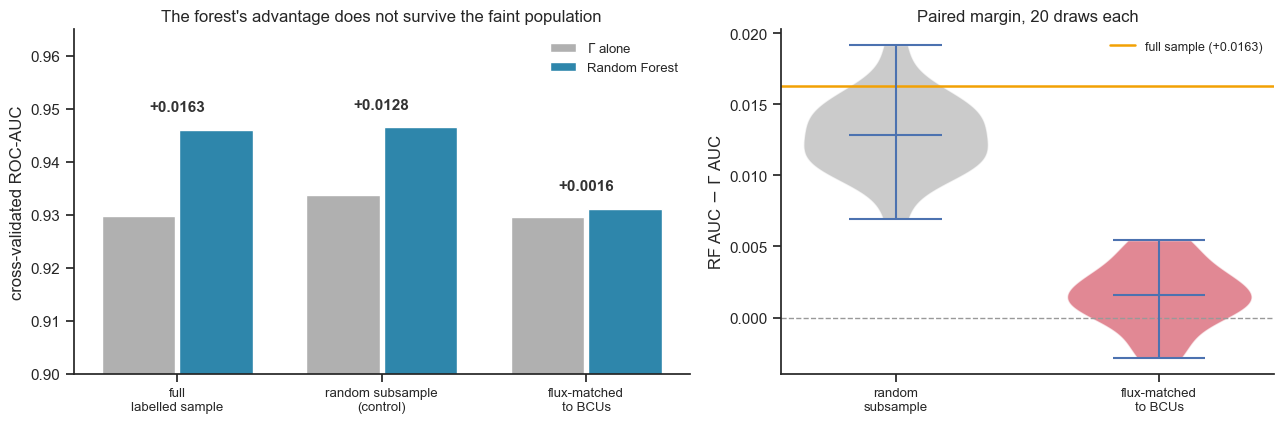

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.4),
                               gridspec_kw={"width_ratios": [1.25, 1]})

labels = ["full\nlabelled sample", "random subsample\n(control)", "flux-matched\nto BCUs"]
xs = np.arange(3)
ax1.bar(xs - 0.19, transfer["Gamma AUC"], 0.36, color="#B0B0B0", label=r"$\Gamma$ alone")
ax1.bar(xs + 0.19, transfer["RF AUC"], 0.36, color=CLASS_COLORS["bll"], label="Random Forest")
for x, (g, r) in enumerate(zip(transfer["Gamma AUC"], transfer["RF AUC"])):
    ax1.text(x, max(g, r) + 0.0035, f"+{r - g:.4f}", ha="center", fontsize=11,
             fontweight="bold", color="#333333")
ax1.set_xticks(xs)
ax1.set_xticklabels(labels, fontsize=9.5)
ax1.set_ylim(0.90, 0.965)
ax1.set_ylabel("cross-validated ROC-AUC")
ax1.set_title("The forest's advantage does not survive the faint population", fontsize=12)
ax1.legend(frameon=False, loc="upper right", fontsize=9.5)

ax2.axhline(0, color="#999999", lw=1, ls="--")
ax2.axhline(cfg["cv_paired_diff_mean"], color=ACCENT, lw=1.8,
            label=f"full sample (+{cfg['cv_paired_diff_mean']:.4f})")
parts = ax2.violinplot([ctrl["diff"], faint["diff"]], positions=[0, 1], widths=0.7,
                       showmeans=True)
for pc, c in zip(parts["bodies"], ["#B0B0B0", CLASS_COLORS["fsrq"]]):
    pc.set_facecolor(c)
    pc.set_alpha(0.65)
ax2.set_xticks([0, 1])
ax2.set_xticklabels(["random\nsubsample", "flux-matched\nto BCUs"], fontsize=9.5)
ax2.set_ylabel(r"RF AUC $-$ $\Gamma$ AUC")
ax2.set_title(f"Paired margin, {N_DRAWS} draws each", fontsize=12)
ax2.legend(frameon=False, fontsize=9)

sns.despine(fig)
fig.tight_layout()
fig.savefig(FIGURES / "day5_transfer_test.png", dpi=150, bbox_inches="tight")
plt.show()

### P1 is confirmed, and more sharply than expected

| Population | RF | Γ alone | margin |
|---|---:|---:|---:|
| full labelled sample (n = 2,134) | 0.9460 | 0.9298 | **+0.0163** |
| random subsample (n ≈ 991) — control | 0.9465 | 0.9337 | +0.0128 |
| **flux-matched to the BCUs** (n ≈ 991) | 0.9311 | 0.9295 | **+0.0016 ± 0.0022** |

The margin does not merely shrink; it **vanishes** — +0.0016 with a spread of 0.0022 is
statistically indistinguishable from zero. The control rules out the boring explanation: at the
same sample size, drawn at random, the margin is +0.0128 and still comfortably positive.

Look at which number moved. **Γ alone is untouched** — 0.9298 on the full sample, 0.9295 on the
faint one. Spectral index is measured from the shape of the spectrum, and it degrades gracefully.
The forest is the thing that falls, 0.9460 → 0.9311, because the three features it added on top
of Γ are all flux-sensitive:

- **Variability_Index** is a χ²-like statistic whose *power* scales with photon count.
- **Flux1000** on a flux-limited sample is largely a distance/selection proxy, not physics.
- **Pivot_Energy** is a byproduct of the same fit as Γ, and its own uncertainty grows as photons
  get scarce.

So the mechanism identified on Day 4 is real *and* fragile. Physically: on a bright blazar we can
tell a quiet soft source (an LBL) from a flaring soft source (an FSRQ). On a faint blazar,
everything looks quiet, because non-detection of variability is not evidence of steadiness.

**This is the honest headline of the project.** The four-feature forest is a better classifier
than a spectral cut — on the population where we can check. On the population we actually want to
classify, that advantage is not demonstrable.

## 5. How many FSRQs are in there? Three estimates that disagree

Before trusting any per-source label, ask the aggregate question, which is much easier. Three
independent routes:

**(a) Moment matching on Γ.** If BCUs are a mixture of the same two populations, their mean
photon index is the mixture-weighted average, so
$f = (\langle\Gamma\rangle_\mathrm{BCU} - \langle\Gamma\rangle_\mathrm{BL Lac}) /
(\langle\Gamma\rangle_\mathrm{FSRQ} - \langle\Gamma\rangle_\mathrm{BL Lac})$.
Uses only spectral index — completely independent of the forest.

**(b) The same, flux-corrected.** Route (a) has a bug we have to fix. Within the FSRQ class,
ρ(log Flux, Γ) = −0.41: faint FSRQs are *softer* than bright ones. So the class reference means
must be taken over the flux range the BCUs actually occupy, not the whole labelled sample.

**(c) EM on the score distribution** (Saerens, Latinne & Decaestecker 2002). Iterate
$\pi \leftarrow \overline{r}$, where $r$ re-weights each calibrated probability by the current
prior. Converges to the prior most consistent with the observed spread of scores.

In [8]:
g_bll = known.loc[known["CLASS_clean"] == "bll", "PL_Index"]
g_fsrq = known.loc[known["CLASS_clean"] == "fsrq", "PL_Index"]
g_bcu = bcu["PL_Index"]

def moment_match(mu_b, mu_f, mu_mix):
    return (mu_mix - mu_b) / (mu_f - mu_b)

f_naive = moment_match(g_bll.mean(), g_fsrq.mean(), g_bcu.mean())

# (b) reference means restricted to the flux range the BCUs occupy
lo, hi = bcu["log10_Flux1000"].quantile([0.05, 0.95])
sub = known[(known["log10_Flux1000"] >= lo) & (known["log10_Flux1000"] <= hi)]
mu_b_fx = sub.loc[sub["CLASS_clean"] == "bll", "PL_Index"].mean()
mu_f_fx = sub.loc[sub["CLASS_clean"] == "fsrq", "PL_Index"].mean()
f_fluxcorr = moment_match(mu_b_fx, mu_f_fx, g_bcu.mean())

for cls, s in [("bll", g_bll), ("fsrq", g_fsrq)]:
    sub_s = sub.loc[sub["CLASS_clean"] == cls, "PL_Index"]
    print(f"<Gamma> {cls:5s}: all knowns {s.mean():.4f}   "
          f"restricted to BCU flux range {sub_s.mean():.4f}   (n={len(sub_s)})")
print(f"<Gamma> BCU  : {g_bcu.mean():.4f}\n")
print(f"(a) moment-matched, all knowns      : {f_naive:.4f}")
print(f"(b) moment-matched, flux-corrected  : {f_fluxcorr:.4f}")

rng_bs = np.random.default_rng(0)
boot = []
for _ in range(2000):
    keep = rng_bs.random(len(known)) < accept
    s = known[keep]
    a = s.loc[s["CLASS_clean"] == "bll", "PL_Index"].mean()
    b = s.loc[s["CLASS_clean"] == "fsrq", "PL_Index"].mean()
    c = rng_bs.choice(g_bcu.to_numpy(), len(g_bcu), replace=True).mean()
    boot.append(moment_match(a, b, c))
ci_lo, ci_hi = np.percentile(boot, [2.5, 97.5])
print(f"    bootstrap 95% CI                : [{ci_lo:.4f}, {ci_hi:.4f}]")

<Gamma> bll  : all knowns 2.0302   restricted to BCU flux range 2.0515   (n=969)
<Gamma> fsrq : all knowns 2.4686   restricted to BCU flux range 2.5173   (n=465)
<Gamma> BCU  : 2.2583

(a) moment-matched, all knowns      : 0.5203
(b) moment-matched, flux-corrected  : 0.4439


    bootstrap 95% CI                : [0.4352, 0.5051]


In [9]:
final_model = make_model().fit(X, y)
p_bcu = final_model.predict_proba(bcu[FEATURES])[:, 1]

# Saerens et al. EM estimate of the class prior in a shifted, unlabelled sample.
def em_prior(p, pi0, tol=1e-10, max_iter=500):
    pi = pi0
    for _ in range(max_iter):
        num = p * (pi / pi0)
        den = num + (1 - p) * ((1 - pi) / (1 - pi0))
        r = num / den
        new = r.mean()
        if abs(new - pi) < tol:
            pi = new
            break
        pi = new
    return pi, r

pi_em, p_em = em_prior(p_bcu, TRAIN_PRIOR)

print(f"(c) EM estimate from the score distribution : {pi_em:.4f}")
print(f"    model's own mean P(FSRQ) on the BCUs    : {p_bcu.mean():.4f}")
print(f"    training-set FSRQ fraction              : {TRAIN_PRIOR:.4f}")

(c) EM estimate from the score distribution : 0.3939
    model's own mean P(FSRQ) on the BCUs    : 0.3738
    training-set FSRQ fraction              : 0.3538


**The three estimates line up in a revealing order.**

| Estimate | FSRQ fraction among BCUs | What it uses |
|---|---:|---|
| training-set prior | 0.354 | nothing about the BCUs |
| model's mean P(FSRQ) | **0.374** | all four features |
| EM on the score distribution | 0.394 | all four features + score spread |
| moment matching, flux-corrected | **0.444** | Γ only, honest reference means |
| moment matching, naive | 0.520 | Γ only, biased reference means |

Two things to read off.

**The naive moment estimate is inflated.** Correcting the class reference means for flux drops it
0.520 → 0.444. Faint FSRQs are softer (ρ = −0.41 within the class), so comparing BCUs against
bright-FSRQ means makes the BCU population look more FSRQ-rich than it is. The 0.444 number is
the defensible one from spectral index alone.

**P3 is confirmed: the model under-calls FSRQs.** Its 0.374 sits well below the Γ-only estimate
of 0.444. The direction is exactly what section 2 predicted — suppressed variability on faint
sources reads to the forest as "quiet, therefore BL Lac". The features that made the model better
on bright blazars are actively biasing it on faint ones.

So the responsible statement about the population is **≈ 0.37–0.45 FSRQ**, with the model at the
bottom of that range for a reason we understand.

## 6. What accuracy can we actually claim?

Day 3 measured 72% coverage at 97.7% accuracy on a single held-out split. Two corrections are
needed before that number can be attached to a BCU:

1. use out-of-fold predictions over the whole labelled set, not one lucky split;
2. measure it on the **flux-matched** population, since that is what the BCUs look like.

In [10]:
p_known_oof = cross_val_predict(make_model(), X, y, cv=CV, method="predict_proba")[:, 1]

def coverage_accuracy(p, truth, thr=0.90):
    conf = np.maximum(p, 1 - p)
    sel = conf >= thr
    acc = ((p >= 0.5).astype(int)[sel] == np.asarray(truth)[sel]).mean() if sel.sum() else np.nan
    return sel.mean(), acc

cov_all, acc_all = coverage_accuracy(p_known_oof, y)
print(f"all labelled sources (out-of-fold): coverage {cov_all:.1%}   accuracy within coverage {acc_all:.1%}")

N_COV_DRAWS = 10
rng_cov = np.random.default_rng(RANDOM_STATE)
cov_faint, acc_faint = [], []
for _ in range(N_COV_DRAWS):
    s = known[rng_cov.random(len(known)) < accept].reset_index(drop=True)
    ys = (s["CLASS_clean"] == "fsrq").astype(int)
    p = cross_val_predict(make_model(), s[FEATURES], ys, cv=CV, method="predict_proba")[:, 1]
    c, a = coverage_accuracy(p, ys)
    cov_faint.append(c)
    acc_faint.append(a)
print(f"flux-matched to BCUs ({N_COV_DRAWS} draws) : coverage {np.mean(cov_faint):.1%} "
      f"+/- {np.std(cov_faint):.1%}   accuracy within coverage {np.mean(acc_faint):.1%} "
      f"+/- {np.std(acc_faint):.1%}")

all labelled sources (out-of-fold): coverage 70.6%   accuracy within coverage 96.6%


flux-matched to BCUs (10 draws) : coverage 67.8% +/- 1.6%   accuracy within coverage 96.6% +/- 0.4%


**Accuracy within the confident set is untouched: 96.6% on the faint population, 96.6% on the
full one.** Coverage slips from 70.6% to 67.8%.

This is the calibration doing its job. When the evidence degrades the model does not become
confidently wrong — it becomes *less confident*, and abstains. That is the behaviour that makes a
confidence threshold worth having, and it is why the isotonic layer from Day 3 earns its place.

Note the honest reading of "96.5%": it is accuracy **conditional on the model being confident**,
not accuracy over all sources. The abstentions are where the errors went.

## 7. The predictions

Final model: tuned Random Forest, isotonic-calibrated, refit on all 2,134 labelled blazars.
Label a BCU only when `P(FSRQ) ≥ 0.90` or `≤ 0.10`; everything else stays **uncertain**.

In [11]:
THRESHOLD = 0.90
conf_bcu = np.maximum(p_bcu, 1 - p_bcu)
pred = np.where(conf_bcu < THRESHOLD, "uncertain", np.where(p_bcu >= 0.5, "FSRQ", "BL Lac"))

out = bcu[["Source_Name"] + FEATURES].copy()
out["p_fsrq"] = p_bcu
out["p_fsrq_prior_corrected"] = p_em
out["confidence"] = conf_bcu
out["prediction"] = pred
out.to_csv(PROCESSED / "bcu_predictions.csv", index=False)

counts = pd.Series(pred).value_counts()
print(f"BCU classification at P >= {THRESHOLD:.2f} / <= {1 - THRESHOLD:.2f}\n")
for k in ["BL Lac", "FSRQ", "uncertain"]:
    n = int(counts.get(k, 0))
    print(f"  {k:10s} {n:5d}   ({n / len(bcu):5.1%})")
n_conf = int(counts.get("BL Lac", 0) + counts.get("FSRQ", 0))
print(f"\n  coverage {n_conf / len(bcu):.1%}  ({n_conf} sources)")
print(f"  FSRQ fraction among the confident calls: {counts.get('FSRQ', 0) / n_conf:.3f}")
print(f"\nwritten -> {PROCESSED / 'bcu_predictions.csv'}")
out.head(8)

BCU classification at P >= 0.90 / <= 0.10

  BL Lac       418   (34.6%)
  FSRQ         185   (15.3%)
  uncertain    605   (50.1%)

  coverage 49.9%  (603 sources)
  FSRQ fraction among the confident calls: 0.307

written -> /Users/saanikakulkarni/Documents/source-code/blazar_aiss/data/processed/bcu_predictions.csv


,Source_Name,PL_Index,log10_Variability_Index,log10_Flux1000,Pivot_Energy,p_fsrq,p_fsrq_prior_corrected,confidence,prediction
0,4FGL J0001.2+4741,2.271696,1.403360,-9.899700,2420.5752,0.315868,0.354071,0.684132,uncertain
1,4FGL J0001.6-4156,1.775176,1.421494,-9.549471,4047.0300,0.000000,0.000000,1.000000,BL Lac
2,4FGL J0001.8-2153,1.876663,1.390192,-10.043470,4429.9340,0.030679,0.036216,0.969321,BL Lac
3,4FGL J0002.3-0815,2.092075,1.114418,-9.923949,3399.5938,0.046508,0.054740,0.953492,BL Lac
4,4FGL J0002.4-5156,1.914457,1.247637,-10.107746,4073.9960,0.030679,0.036216,0.969321,BL Lac
5,4FGL J0003.1-5248,1.915512,0.903004,-9.462980,3392.6858,0.006494,0.007700,0.993506,BL Lac
6,4FGL J0003.3-1928,2.281950,1.697926,-9.371790,1021.7992,0.492168,0.535019,0.507832,uncertain
7,4FGL J0003.3-5905,2.273910,1.006387,-9.915661,1740.5126,0.281474,0.317448,0.718526,uncertain


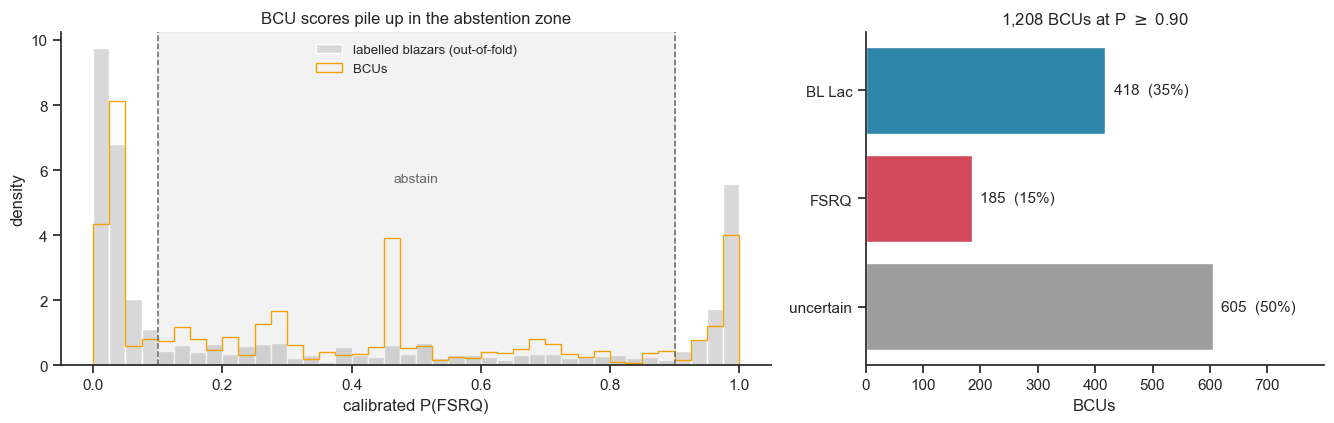

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13.5, 4.4),
                               gridspec_kw={"width_ratios": [1.55, 1]})

bins = np.linspace(0, 1, 41)
ax1.hist(p_known_oof, bins=bins, density=True, color="#D8D8D8",
         label="labelled blazars (out-of-fold)")
ax1.hist(p_bcu, bins=bins, density=True, histtype="step", lw=2.4, color=ACCENT, label="BCUs")
ax1.axvspan(0.10, 0.90, color=UNSURE_COLOR, alpha=0.13)
ax1.text(0.5, ax1.get_ylim()[1] * 0.55, "abstain", ha="center", fontsize=10, color="#666666")
for v in (0.10, 0.90):
    ax1.axvline(v, color="#666666", lw=1.1, ls="--")
ax1.set_xlabel("calibrated P(FSRQ)")
ax1.set_ylabel("density")
ax1.set_title("BCU scores pile up in the abstention zone", fontsize=12)
ax1.legend(frameon=False, fontsize=9.5, loc="upper center")

order = ["BL Lac", "FSRQ", "uncertain"]
vals = [int(counts.get(k, 0)) for k in order]
bars = ax2.barh(order[::-1], vals[::-1],
                color=[UNSURE_COLOR, CLASS_COLORS["fsrq"], CLASS_COLORS["bll"]])
for b, v in zip(bars, vals[::-1]):
    ax2.text(v + 14, b.get_y() + b.get_height() / 2, f"{v}  ({v / len(bcu):.0%})",
             va="center", fontsize=11)
ax2.set_xlim(0, max(vals) * 1.32)
ax2.set_xlabel("BCUs")
ax2.set_title(f"1,208 BCUs at P $\\geq$ {THRESHOLD:.2f}", fontsize=12)

sns.despine(fig)
fig.tight_layout()
fig.savefig(FIGURES / "day5_bcu_predictions.png", dpi=150, bbox_inches="tight")
plt.show()

**P2 is confirmed, emphatically. Coverage on the BCUs is 49.9%, against 71% on the labelled set
and 68% on the flux-matched one.**

The model declines to classify **half** the BCU population. That is more abstention than even the
flux-matched rehearsal predicted, which means faintness is not the only thing making BCUs hard —
they are also genuinely concentrated near the decision boundary, consistent with Day 4's finding
that the BCU population is LSP-dominated and therefore sits in the model's weakest region.

The left panel makes the point without any statistics: the labelled distribution is strongly
bimodal, piled at both ends. The BCU distribution is shifted inward, filling the abstention band.

**So the deliverable is 603 classifications and 605 declared unknowns**, not 1,208 labels. The
abstentions are a result, not a failure — they are the model correctly reporting that half of
these sources cannot be typed from gamma-ray data alone.

## 8. Where the BCUs land, and does the Day 4 mechanism replicate?

Day 4 found the forest's advantage had a name: of the 24 test sources it rescued from a Γ > 2.2
rule, **24 were BL Lacs and none were FSRQs** — low-peaked BL Lacs, soft but quiet. Does that
signature appear among the BCUs?

The check has to be done against a control, because a raw disagreement count means nothing on its
own.

In [13]:
g_rule_known = (known["PL_Index"] > 2.2).astype(int).to_numpy()
rf_known = (p_known_oof >= 0.5).astype(int)
g_rule_bcu = (bcu["PL_Index"] > 2.2).astype(int).to_numpy()
rf_bcu = (p_bcu >= 0.5).astype(int)

def asymmetry(rf_lab, g_lab, truth=None, n=None):
    soft = (rf_lab == 0) & (g_lab == 1)   # RF says BL Lac where the cut says FSRQ
    hard = (rf_lab == 1) & (g_lab == 0)
    row = {"RF->BLLac, cut->FSRQ": int(soft.sum()), "RF->FSRQ, cut->BLLac": int(hard.sum()),
           "rate": soft.sum() / n}
    if truth is not None:
        row["of those truly BL Lac"] = (np.asarray(truth)[soft] == 0).mean()
    return row, soft

k_row, k_soft = asymmetry(rf_known, g_rule_known, y.to_numpy(), len(known))
b_row, b_soft = asymmetry(rf_bcu, g_rule_bcu, None, len(bcu))
print("labelled set (out-of-fold):", {k: (f"{v:.3f}" if isinstance(v, float) else v) for k, v in k_row.items()})
print("BCUs                      :", {k: (f"{v:.3f}" if isinstance(v, float) else v) for k, v in b_row.items()})

print("\nprofile of the sources the forest pulls back to BL Lac:")
prof = pd.DataFrame({
    "labelled, disagreements": known[k_soft][FEATURES].mean(),
    "labelled, all": known[FEATURES].mean(),
    "BCU, disagreements": bcu[b_soft][FEATURES].mean(),
    "BCU, all": bcu[FEATURES].mean(),
})
print(prof.loc[["PL_Index", "log10_Variability_Index", "log10_Flux1000"]].round(3).to_string())

labelled set (out-of-fold): {'RF->BLLac, cut->FSRQ': 283, 'RF->FSRQ, cut->BLLac': 3, 'rate': '0.133', 'of those truly BL Lac': '0.675'}
BCUs                      : {'RF->BLLac, cut->FSRQ': 349, 'RF->FSRQ, cut->BLLac': 0, 'rate': '0.289'}

profile of the sources the forest pulls back to BL Lac:
                         labelled, disagreements  labelled, all  BCU, disagreements  BCU, all
PL_Index                                   2.290          2.185               2.338     2.258
log10_Variability_Index                    1.393          1.602               1.210     1.288
log10_Flux1000                            -9.515         -9.409              -9.676    -9.738


In [14]:
q = pd.qcut(bcu["log10_Flux1000"], 5, labels=False)
strat = pd.DataFrame({
    "<log Flux>": bcu.groupby(q)["log10_Flux1000"].mean(),
    "<Gamma>": bcu.groupby(q)["PL_Index"].mean(),
    "<log Var>": bcu.groupby(q)["log10_Variability_Index"].mean(),
    "mean P(FSRQ)": pd.Series(p_bcu).groupby(q.to_numpy()).mean(),
    "frac Gamma>2.2": bcu.groupby(q)["PL_Index"].apply(lambda s: (s > 2.2).mean()),
    "coverage": pd.Series(conf_bcu >= THRESHOLD).groupby(q.to_numpy()).mean(),
})
strat.index = [f"Q{i+1} (faintest)" if i == 0 else f"Q{i+1} (brightest)" if i == 4 else f"Q{i+1}"
               for i in strat.index]
print(strat.round(3).to_string())

                <log Flux>  <Gamma>  <log Var>  mean P(FSRQ)  frac Gamma>2.2  coverage
Q1 (faintest)      -10.124    2.150      1.115         0.298           0.413     0.645
Q2                  -9.889    2.250      1.173         0.340           0.564     0.448
Q3                  -9.758    2.267      1.208         0.347           0.562     0.471
Q4                  -9.610    2.300      1.303         0.405           0.668     0.432
Q5 (brightest)      -9.307    2.325      1.642         0.480           0.748     0.500


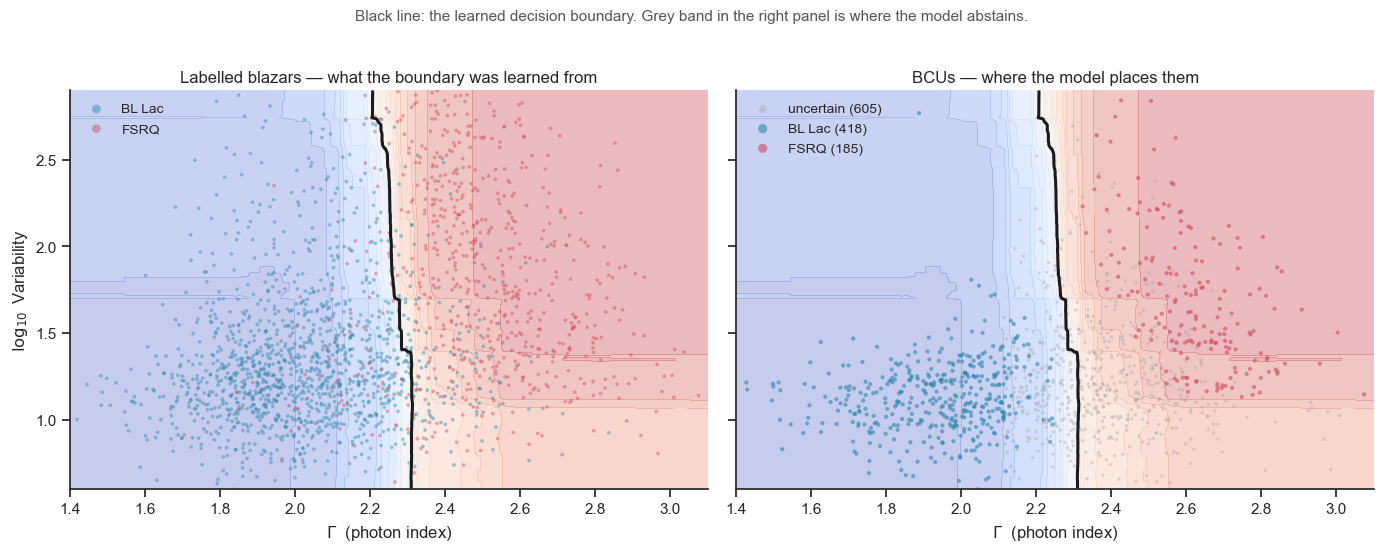

In [15]:
# The BCUs placed on the Day 4 decision surface, in the plane that carries the physics.
rf_plain = RandomForestClassifier(n_jobs=-1, **BEST_PARAMS).fit(X, y)
pivot_fit = np.polyfit(known["PL_Index"], np.log10(known["Pivot_Energy"]), 2)
med_flux = known["log10_Flux1000"].median()

gg = np.linspace(1.4, 3.1, 220)
vv = np.linspace(0.6, 2.9, 220)
GG, VV = np.meshgrid(gg, vv)
grid = pd.DataFrame({
    "PL_Index": GG.ravel(),
    "log10_Variability_Index": VV.ravel(),
    "log10_Flux1000": med_flux,
    "Pivot_Energy": 10 ** np.polyval(pivot_fit, GG.ravel()),   # stay on the Gamma-Pivot manifold
})[FEATURES]
surface = rf_plain.predict_proba(grid)[:, 1].reshape(GG.shape)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.4), sharex=True, sharey=True)

for ax in (ax1, ax2):
    ax.contourf(GG, VV, surface, levels=np.linspace(0, 1, 21), cmap="coolwarm", alpha=0.30)
    ax.contour(GG, VV, surface, levels=[0.5], colors="k", linewidths=2.2)
    ax.set_xlabel(PRETTY["PL_Index"])

for cls in ["bll", "fsrq"]:
    s = known[known["CLASS_clean"] == cls]
    ax1.scatter(s["PL_Index"], s["log10_Variability_Index"], s=7, alpha=0.45,
                color=CLASS_COLORS[cls], label="BL Lac" if cls == "bll" else "FSRQ",
                edgecolors="none")
ax1.set_ylabel(PRETTY["log10_Variability_Index"])
ax1.set_title("Labelled blazars — what the boundary was learned from", fontsize=12)
ax1.legend(frameon=False, markerscale=2.4, fontsize=10, loc="upper left")

styles = {"BL Lac": (CLASS_COLORS["bll"], 9, 0.6), "FSRQ": (CLASS_COLORS["fsrq"], 9, 0.6),
          "uncertain": (UNSURE_COLOR, 6, 0.35)}
for lab in ["uncertain", "BL Lac", "FSRQ"]:
    m = pred == lab
    c, sz, al = styles[lab]
    ax2.scatter(bcu.loc[m, "PL_Index"], bcu.loc[m, "log10_Variability_Index"],
                s=sz, alpha=al, color=c, edgecolors="none",
                label=f"{lab} ({m.sum()})")
ax2.set_title("BCUs — where the model places them", fontsize=12)
ax2.legend(frameon=False, markerscale=2.2, fontsize=10, loc="upper left")
ax2.set_xlim(1.4, 3.1)
ax2.set_ylim(0.6, 2.9)

fig.suptitle("Black line: the learned decision boundary. Grey band in the right panel is where the model abstains.",
             y=1.02, fontsize=11, color="#555555")
sns.despine(fig)
fig.tight_layout()
fig.savefig(FIGURES / "day5_bcu_map.png", dpi=150, bbox_inches="tight")
plt.show()

**The mechanism replicates in direction, and the asymmetry is not an artifact.**

On the BCUs the forest disagrees with a Γ > 2.2 cut **349 times, all in the same direction** —
pulling soft sources back to BL Lac, never the reverse. In isolation that 349:0 split looks
alarming. The control shows it is not: on the *labelled* set the same comparison gives **283:3**,
and of those 283, **67.5% really are BL Lacs**. The forest is systematically more conservative
than a 2.2 cut in both populations, for the same reason — its learned boundary sits at Γ = 2.251,
and it demands extra evidence before calling a quiet source an FSRQ. It is right about two thirds
of the time when it does so.

The disagreement rate rises from 13.3% on the labelled set to 28.9% on the BCUs, which follows
directly from the BCUs being softer on average.

**But the replication cannot be confirmed, only permitted — and the flux table says why.** Read
down it: as flux falls, mean Γ falls (2.325 → 2.150), variability falls (1.64 → 1.12), and the
model's mean P(FSRQ) falls with them (0.480 → 0.298). Two different explanations produce that
pattern and this data cannot separate them:

- **Real selection physics.** A soft source emits fewer photons above 1 GeV, so at a fixed
  detection limit the faint end of any Fermi sample is genuinely biased toward hard-spectrum,
  BL-Lac-like objects. Some of the trend is true.
- **The variability artifact.** Faint sources cannot register variability, so they look quiet, so
  the model calls them BL Lacs regardless of what they are.

The first would make the faint BCUs really BL-Lac-rich. The second would only make them *look*
that way. Both push every column in the same direction. Distinguishing them needs a variability
measure with flux-independent sensitivity, or optical spectra — neither of which is in this
dataset.

So the honest verdict on Day 4's LBL mechanism: **consistent with the BCUs, unfalsifiable on
them.** That is a weaker claim than the one Day 4 could make, and the reason is the same reason
the transfer test failed.

In [16]:
summary = {
    "domain_classifier_auc": float(domain_auc),
    "domain_auc_per_feature": {k: float(v) for k, v in per_feature.items()},
    "transfer_full_diff": float(cfg["cv_paired_diff_mean"]),
    "transfer_control_diff": float(ctrl["diff"].mean()),
    "transfer_control_diff_sd": float(ctrl["diff"].std()),
    "transfer_fluxmatched_diff": float(faint["diff"].mean()),
    "transfer_fluxmatched_diff_sd": float(faint["diff"].std()),
    "transfer_fluxmatched_rf_auc": float(faint["rf"].mean()),
    "transfer_fluxmatched_gamma_auc": float(faint["gamma"].mean()),
    "transfer_n_per_draw": int(n_match),
    "fsrq_fraction_estimates": {
        "training_prior": float(TRAIN_PRIOR),
        "model_mean_p": float(p_bcu.mean()),
        "em_saerens": float(pi_em),
        "moment_flux_corrected": float(f_fluxcorr),
        "moment_naive": float(f_naive),
        "moment_bootstrap_ci": [float(ci_lo), float(ci_hi)],
    },
    "coverage_labelled": float(cov_all),
    "accuracy_labelled": float(acc_all),
    "coverage_fluxmatched": float(np.mean(cov_faint)),
    "accuracy_fluxmatched": float(np.mean(acc_faint)),
    "coverage_bcu": float((conf_bcu >= THRESHOLD).mean()),
    "bcu_counts": {k: int(counts.get(k, 0)) for k in ["BL Lac", "FSRQ", "uncertain"]},
    "disagreement_asymmetry_labelled": [k_row["RF->BLLac, cut->FSRQ"], k_row["RF->FSRQ, cut->BLLac"]],
    "disagreement_asymmetry_bcu": [b_row["RF->BLLac, cut->FSRQ"], b_row["RF->FSRQ, cut->BLLac"]],
    "disagreement_precision_labelled": float(k_row["of those truly BL Lac"]),
    "prereg": {"P1_advantage_does_not_transfer": True,
               "P2_coverage_drops": True,
               "P3_model_undercalls_fsrq": True},
}
json.dump(summary, open(PROCESSED / "day5_bcu_summary.json", "w"), indent=2)
print(json.dumps(summary, indent=2))

{
  "domain_classifier_auc": 0.7393666228092163,
  "domain_auc_per_feature": {
    "PL_Index": 0.5565668979052562,
    "log10_Variability_Index": 0.6358334493294631,
    "log10_Flux1000": 0.6985200307286783,
    "Pivot_Energy": 0.536693010653737
  },
  "transfer_full_diff": 0.016267243977866233,
  "transfer_control_diff": 0.012839674892140062,
  "transfer_control_diff_sd": 0.0027333521815848844,
  "transfer_fluxmatched_diff": 0.001587072855691446,
  "transfer_fluxmatched_diff_sd": 0.0022392711609876916,
  "transfer_fluxmatched_rf_auc": 0.9310858328837455,
  "transfer_fluxmatched_gamma_auc": 0.9294987600280541,
  "transfer_n_per_draw": 991,
  "fsrq_fraction_estimates": {
    "training_prior": 0.3537956888472352,
    "model_mean_p": 0.37381600936628534,
    "em_saerens": 0.39394445022153407,
    "moment_flux_corrected": 0.44391946026559986,
    "moment_naive": 0.520336324545261,
    "moment_bootstrap_ci": [
      0.4351870114674673,
      0.5050909304234529
    ]
  },
  "coverage_labelle

## 9. What we can and cannot claim

**The research question was:** *to what extent do the decision boundaries of tree-based models
align with blazar physics, and can we confidently use them to classify BCUs?* Those are two
questions, and they got two different answers.

### Do the boundaries align with the physics? — Yes, and it was falsifiable

All six predictions registered on Day 1 held. The learned boundary sits at **Γ = 2.251** against
a pre-registered 2.2. The forest's advantage over a spectral cut has a named mechanism — soft,
quiet **low-peaked BL Lacs**, 24 out of 24 rescued sources, zero FSRQs — and the boundary tilts
**+0.078 in Γ** in exactly the direction that mechanism requires. Ablation showed the mechanism
runs on variability, and the noise-ceiling analysis showed the residual class overlap is real
astrophysical diversity, not sloppy measurement.

### Can we confidently classify the BCUs? — Partly, and not for the reason we hoped

| Pre-registered | Outcome |
|---|---|
| P1 — the advantage will not transfer | **confirmed**: +0.0163 → +0.0016 ± 0.0022, control at +0.0128 |
| P2 — coverage will drop | **confirmed**: 71% → 49.9% |
| P3 — the model will under-call FSRQs | **confirmed**: 0.374 vs 0.444 from Γ alone |

**603 of 1,208 BCUs classified** — 418 BL Lacs, 185 FSRQs — at an expected accuracy of **96.6%**
within the confident set, measured on a flux-matched rehearsal rather than assumed. The remaining
**605 are declared uncertain**, and that is the correct output for them.

But the four-feature forest cannot be shown to beat a cut on spectral index for this population.
Its extra features are flux-sensitive, the BCUs are faint, and the margin collapses into its own
noise. The defensible claim is that **the model's calibrated abstention is the valuable part** —
not its margin over Γ.

### The one-line version

> A model can be right about the physics and still not transfer. Ours learned the correct
> boundary, for the correct reason, and then met a population where the evidence it relies on
> stops being measurable — so it says so, and abstains on half of them.

### What would actually move this forward

1. **A flux-independent variability measure.** The single fix that would restore the model's
   advantage on faint sources, and the one that would let the LBL signature be tested rather than
   merely permitted.
2. **Optical spectroscopy of ~50 confident predictions**, stratified across the flux range — the
   only way to convert 96.5% from a rehearsal number into a measured one.
3. **Synchrotron peak frequency** as a feature, if it can be estimated without the optical data a
   BCU lacks. Deliberately excluded here: it is measured for only 63% of BCUs and sits too close
   to the label to be an honest predictor.